
# Object Detection with Mini‑YOLO From Scratch

In this notebook, we learn the core ideas of YOLO object detection (grids, bounding boxes, confidence, loss, inference) with a small synthetic dataset:

- We synthesize simple images with rectangles/circles/triangles.
- We train a tiny YOLO‑style model using a single box per cell and a single class from scratch.
- We apply Non-Maximum Suppression (NMS), visualize predictions and tweak hyperparameters.


In [1]:

# Setup
import math, random, os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision.ops as ops
import cv2

# Reproducibility
random.seed(5)
np.random.seed(5)
torch.manual_seed(5)



## 1. Synthetic Shapes Dataset

First, we generate 128×128 RGB images with 1–3 random shapes (rectangle/circle/triangle).  
The target for each image is a list of bounding boxes `[x1, y1, x2, y2]` (pixel coordinates).

We keep one class (shape=1) to simplify the loss and metrics.


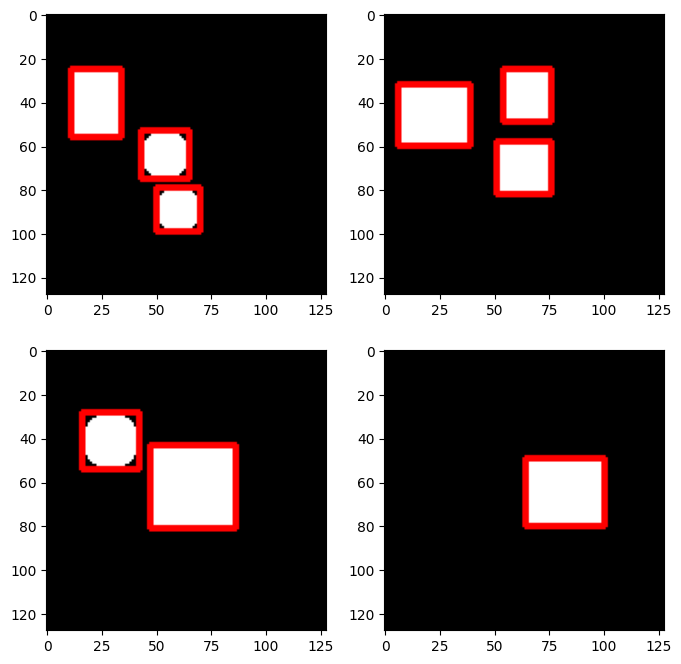

In [2]:
IMG_SIZE = 128

def draw_random_shape(img, shape_type=None):
    """Draw a random shape on img and return its bounding box and mask."""
    h, w, _ = img.shape
    if shape_type is None:
        shape_type = random.choice(["rect", "circle", "tri"])

    mask = np.zeros((h, w), dtype=np.uint8)
    x1 = random.randint(5, w-45)
    y1 = random.randint(5, h-45)
    x2 = x1 + random.randint(20, 40)
    y2 = y1 + random.randint(20, 40)

    if shape_type == "rect":
        cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
    elif shape_type == "circle":
        cx, cy = (x1+x2)//2, (y1+y2)//2
        r = min((x2-x1)//2, (y2-y1)//2)
        cv2.circle(mask, (cx, cy), r, 255, -1)
    else:  # triangle
        pts = np.array([[x1, y2], [x2, y2], [x1 + (x2-x1)//2, y1]], dtype=np.int32)
        cv2.fillConvexPoly(mask, pts, 255)

    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None, None  # skip invalid shapes

    box = [xs.min(), ys.min(), xs.max(), ys.max()]
    return box, mask

# Define Dataset
class ShapesDataset(Dataset):
    def __init__(self, n=500, img_size=128, max_objs=3):
        self.n = n
        self.img_size = img_size
        self.max_objs = max_objs

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        occ_mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)  # tracks occupied pixels
        boxes = []

        for _ in range(random.randint(1, self.max_objs)):
            for _ in range(50):  # more attempts
                box, mask = draw_random_shape(np.zeros_like(img))
                if box is None:
                    continue
                # Check pixel overlap (no >1% overlap allowed)
                intersection = np.logical_and(mask > 0, occ_mask > 0).sum()
                union = (mask > 0).sum() + (occ_mask > 0).sum()
                iou_pix = intersection / max(union, 1)
                if iou_pix < 0.01:
                    # Draw accepted shape
                    img[mask > 0] = 255
                    occ_mask[mask > 0] = 255
                    boxes.append(box)
                    break

        img_t = torch.from_numpy(img.astype(np.float32)).permute(2,0,1)
        boxes_t = torch.tensor(boxes, dtype=torch.float32)
        labels_t = torch.ones((len(boxes),), dtype=torch.long)
        return img_t, {"boxes": boxes_t, "labels": labels_t}


# Sanity check: visualize some samples
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

ds = ShapesDataset(n=4)
for i in range(4):
    img_t, tgt = ds[i]
    img_np = (img_t.permute(1,2,0).numpy()).astype(np.uint8)
    for (x1, y1, x2, y2) in tgt["boxes"].numpy().astype(int):
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (255,0,0), 2)
    axes[i].imshow(img_np)

plt.show()



## 2. YOLO‑style Target Encoding

Now we encode our targets in YOLO compatible format: We use a grid of size `SxS` (here `7x7`) and store for each cell the center coordinates, width, height and confidence of the targets: `[x, y, w, h, conf]`. 
Note that the conficence is also called objectness score in later YOLO versions. The confidence is always 1 for our targets. YOLO uses coordinates normalized to [0,1] relative to the image. If a box center falls into a cell, that cell holds the box. We allow one box per cell as simplification - note that we are not using anchors here, so we are using a network similar to YOLO v1, whereas anchors were introduced in later YOLO versions.


In [3]:

S = 7  # grid size

def encode_yolo_targets(target, grid_size=S, img_size=IMG_SIZE):
    boxes = target["boxes"]
    if boxes.numel() == 0:
        return torch.zeros((grid_size, grid_size, 5), dtype=torch.float32)

    # Normalize to [0,1]
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    xc = ((x1 + x2) / 2) / img_size
    yc = ((y1 + y2) / 2) / img_size
    w  = (x2 - x1) / img_size
    h  = (y2 - y1) / img_size

    cell_x = (xc * grid_size).long()
    cell_y = (yc * grid_size).long()

    # local offset inside the cell (YOLO-style)
    x_rel = xc * grid_size - cell_x.float()
    y_rel = yc * grid_size - cell_y.float()

    y = torch.zeros((grid_size, grid_size, 5), dtype=torch.float32)
    for cx, cy, xr, yr, wv, hv in zip(cell_x, cell_y, x_rel, y_rel, w, h):
        y[cy, cx] = torch.tensor([xr, yr, wv, hv, 1.0])
    return y

# Quick test
_, t = ds[0]
yt = encode_yolo_targets(t, grid_size=S, img_size=IMG_SIZE)
yt.shape, yt[...,4].sum()  # number of cells with object


(torch.Size([7, 7, 5]), tensor(3.))

Now let's visualize some examples with their encoded targets. We will show 2 examples vertically: On the left, the respective image with grid and ground-truth boxes. On the right, the objectness map from the encoded targets.

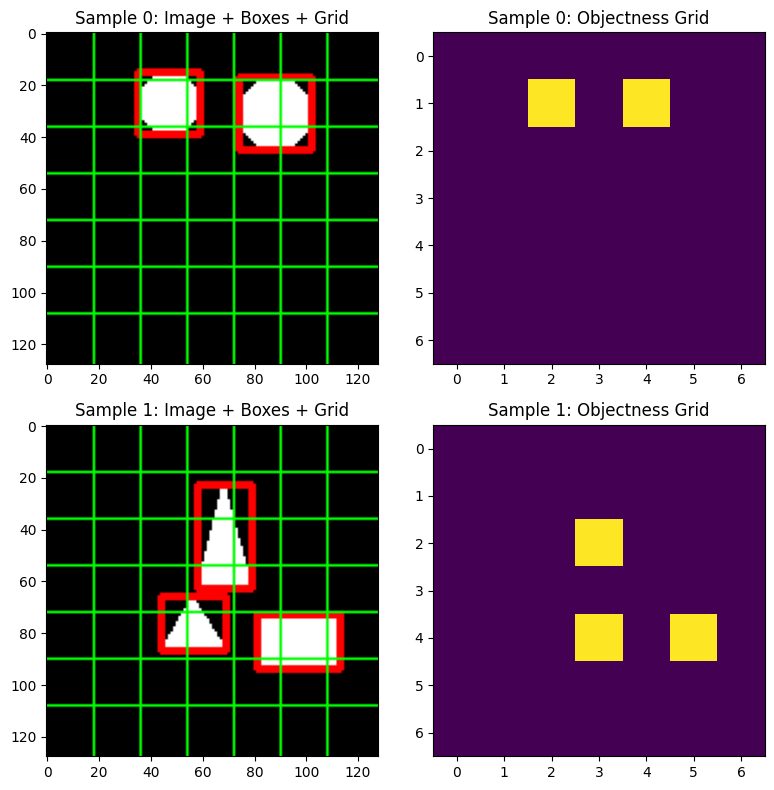

In [4]:
# Show 2 examples vertically

_, axs = plt.subplots(2, 2, figsize=(8, 8))

for row in range(2):
    img_t, tgt = ds[row]
    yt = encode_yolo_targets(tgt)

    img_np = img_t.permute(1,2,0).numpy()

    # Draw boxes
    for (x1, y1, x2, y2) in tgt["boxes"].numpy().astype(int):
        cv2.rectangle(img_np, (x1, y1), (x2, y2), (255,0,0), 2)

    # Draw grid
    cell = IMG_SIZE // S
    for i in range(1, S):
        cv2.line(img_np, (i*cell, 0), (i*cell, IMG_SIZE), (0,255,0), 1)
        cv2.line(img_np, (0, i*cell), (IMG_SIZE, i*cell), (0,255,0), 1)

    # Left: image
    axs[row,0].imshow(img_np.astype(int))
    axs[row,0].set_title(f"Sample {row}: Image + Boxes + Grid")

    # Right: objectness heatmap
    obj = yt[...,4].numpy()
    im = axs[row,1].imshow(obj, cmap="viridis", vmin=0, vmax=1)
    axs[row,1].set_title(f"Sample {row}: Objectness Grid")

plt.tight_layout()
plt.show()



## 3. Mini‑YOLO Model 

Now we define our Mini-YOLO model, using a compact CNN backbone and a detection head. Since we predict only one class, the final output per grid cell has 5 values: `(x, y, w, h, confidence)`. Therefore, the final output shape is `(B, S, S, 5)`, where `B` is the batch size and `S` is the grid size. If needed, we interpolate the result in the forward pass to get to size `SxS`, for example, here we have an intermediate resolution of `8x8` and interpolate to `7x7`.

Note that we do not need fully connected layers at the end because we do not predict global class scores. Instead, we use `1x1`-convolutions to maintain spatial structure and predict per-cell outputs: YOLO is a **Fully Convolutional Network**. 


In [5]:

class MiniYOLO(nn.Module):
    def __init__(self, grid_size=S):
        super().__init__()
        self.S = grid_size
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),  # 64x64
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8
        )
        # Project to SxS
        self.head = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 5, kernel_size=1)  # 5 channels for [x,y,w,h,conf] per spatial position
        )

    def forward(self, x):
        f = self.backbone(x)
        h = self.head(f)                           # (B,5,H',W')
        # Adapt H',W' to SxS via interpolation if needed (here: 8x8 -> 7x7)
        h = F.interpolate(h, size=(self.S, self.S), mode="bilinear", align_corners=False)
        # Sigmoid for [x,y,w,h,conf]
        h = torch.sigmoid(h)
        # (B, S, S, 5)
        return h.permute(0,2,3,1)

model = MiniYOLO(S)



## 4. YOLO Loss Function 

Now we define the YOLO loss function. We use a simplified loss focusing on objectness and bounding box regression. For each grid cell and anchor, the model predicts
a bounding box 
$\hat{b}_i = (\hat{x}_i, \hat{y}_i, \hat{w}_i, \hat{h}_i)$
and an objectness score $\hat{c}_i$. The loss consists of three parts: an IoU-based localization loss, an objectness loss for cells containing an object, and a no-object loss for empty cells. We can weight the components using hyperparameters:

$$\mathcal{L}
= 
\lambda_{\mathrm{coord}} \, \mathcal{L}_{\mathrm{IoU}}
+ \mathcal{L}_{\mathrm{obj}}
+ \lambda_{\mathrm{noobj}} \, \mathcal{L}_{\mathrm{noobj}} .
$$

For all grid cells containing an object, the **IoU Loss** (regression loss) is
$$
\mathcal{L}_{\mathrm{IoU}}
=
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
\left( 1 - \mathrm{IoU}(\hat{b}_i, b_i) \right) .
$$

The second part, the **Objectness Loss**, can be defined for object cells as
$$
\mathcal{L}_{\mathrm{obj}}
=
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
\left( \hat{c}_i - 1 \right)^{2} .
$$

Note that we are using Mean Squared Error (MSE) here like in the original YOLO paper, whereas modern variants rather use Binary Cross Entropy (BCE) Loss. 
Finally, for empty cells, we define the **No-Object Loss**:
$$
\mathcal{L}_{\mathrm{noobj}}
=
\frac{1}{N_{\mathrm{noobj}}}
\sum_{i \in \mathrm{noobj}}
\left( \hat{c}_i - 0 \right)^{2} .
$$

Putting it all together, we get the final loss:
$$ 
\mathcal{L}
=
\lambda_{\mathrm{coord}}
\left(
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
\left( 1 - \mathrm{IoU}(\hat{b}_i, b_i) \right)
\right)
+
\frac{1}{N_{\mathrm{obj}}}
\sum_{i \in \mathrm{obj}}
(\hat{c}_i - 1)^{2}
+
\lambda_{\mathrm{noobj}}
\frac{1}{N_{\mathrm{noobj}}}
\sum_{i \in \mathrm{noobj}}
(\hat{c}_i)^{2}.
$$

In [6]:
# define IoU function
def bbox_iou(box1, box2):
    # box1, box2: (..., 4) in [x,y,w,h]
    x1_min = box1[...,0] - box1[...,2]/2 # x - w/2
    y1_min = box1[...,1] - box1[...,3]/2 # y - h/2
    x1_max = box1[...,0] + box1[...,2]/2 # x + w/2
    y1_max = box1[...,1] + box1[...,3]/2 # y + h/2
    x2_min = box2[...,0] - box2[...,2]/2 # same for box2
    y2_min = box2[...,1] - box2[...,3]/2
    x2_max = box2[...,0] + box2[...,2]/2
    y2_max = box2[...,1] + box2[...,3]/2

    # calculate intersection
    inter_x1 = torch.max(x1_min, x2_min)
    inter_y1 = torch.max(y1_min, y2_min)
    inter_x2 = torch.min(x1_max, x2_max)
    inter_y2 = torch.min(y1_max, y2_max)

    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)
    # calculate union (subtract intersection because counted twice)
    union = area1 + area2 - inter_area
    return inter_area / (union + 1e-6) # avoid dividing by zero

# define YOLO loss function
def yolo_loss(pred, target, lambda_coord=5.0, lambda_noobj=0.5):
    obj_mask = target[...,4] > 0.5 # cells with objects
    noobj_mask = ~obj_mask # cells without objects

    iou = bbox_iou(pred[obj_mask][..., :4], target[obj_mask][..., :4]) # IoU for cells with objects
    iou_loss = (1 - iou).mean() if iou.numel() > 0 else 0 # loss component for bounding box regression = 1 - IoU

    obj_loss = F.mse_loss(pred[obj_mask][..., 4], target[obj_mask][..., 4]) if obj_mask.any() else 0 # objectness loss for cells with objects
    noobj_loss = lambda_noobj * F.mse_loss(pred[noobj_mask][..., 4], target[noobj_mask][..., 4]) if noobj_mask.any() else 0 # objectness loss for cells without objects
    return lambda_coord * iou_loss + obj_loss + noobj_loss



## 5. Dataloaders

Now let's create our dataloaders for training and validation. We encode our targets on the fly to the `(S,S,5)` grid:


In [7]:

def collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack(imgs, dim=0)
    y = torch.stack([encode_yolo_targets(t, grid_size=S, img_size=IMG_SIZE) for t in targets], dim=0)
    return imgs, y

# Create DataLoaders for training and validation
train_ds = ShapesDataset(n=600, max_objs=3)
val_ds   = ShapesDataset(n=120, max_objs=3)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)



## 6. Training

Finally, it is time to train! A short run is enough to see the loss decrease:


In [8]:
# Training loop
model = MiniYOLO(S)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for x, y in loader:
            p = model(x)
            total += yolo_loss(p, y).item()
    return total / max(1,len(loader)) 

EPOCHS = 15
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0 # track training loss

    for x, y in train_loader:
        p = model(x)
        loss = yolo_loss(p, y)
        opt.zero_grad(); 
        loss.backward(); 
        opt.step()
        running += loss.item() # accumulate training loss

    # evaluate on validation set once per epoch
    val_loss = evaluate(val_loader) 
    print(f"Epoch {epoch:02d} | train_loss={running/len(train_loader):.4f} | val_loss={val_loss:.4f}")


Epoch 01 | train_loss=4.1730 | val_loss=4.3571
Epoch 02 | train_loss=3.4048 | val_loss=3.5561
Epoch 03 | train_loss=3.1731 | val_loss=3.2820
Epoch 04 | train_loss=2.9660 | val_loss=3.4960
Epoch 05 | train_loss=2.9505 | val_loss=3.1147
Epoch 06 | train_loss=3.0224 | val_loss=2.7191
Epoch 07 | train_loss=2.7819 | val_loss=3.0892
Epoch 08 | train_loss=2.8022 | val_loss=2.6015
Epoch 09 | train_loss=2.7633 | val_loss=3.1466
Epoch 10 | train_loss=2.7075 | val_loss=2.6714
Epoch 11 | train_loss=2.4677 | val_loss=2.7179
Epoch 12 | train_loss=2.6017 | val_loss=2.7574
Epoch 13 | train_loss=2.6726 | val_loss=2.7549
Epoch 14 | train_loss=2.5313 | val_loss=2.5249
Epoch 15 | train_loss=2.5870 | val_loss=2.4679



## 7. Inference & Visualization

Let's take a look at our results! We pick the cells with object confidence above a certain threshold and draw their predicted boxes:


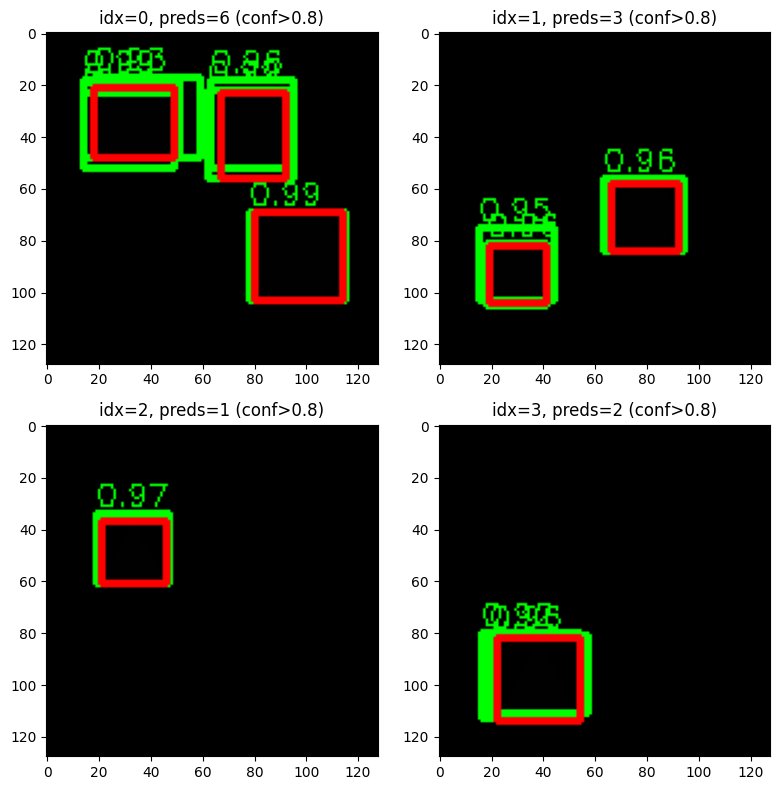

In [9]:
# Show YOLO predictions for 4 samples from dataset at given indices.
def visualize_predictions(model, dataset, indices, conf_thresh=0.8):

    assert len(indices) == 4, "Please pass exactly 4 indices."

    model.eval()
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    for ax, idx in zip(axes.flatten(), indices):
        img_t, target = dataset[idx]

        with torch.no_grad():
            pred = model(img_t.unsqueeze(0))[0].cpu().numpy()   # (S, S, 5)

        img = (img_t.permute(1,2,0).numpy() * 255).astype(np.uint8).copy()
        H = W = IMG_SIZE
        boxes = []

        # Loop over all grid cells
        for cy in range(S):
            for cx in range(S):
                x_rel, y_rel, w, h, conf = pred[cy, cx]
                if conf < conf_thresh:
                    continue

                # Convert to global normalized coords
                x = (cx + x_rel) / S
                y = (cy + y_rel) / S

                # Convert to pixel coordinates
                x1 = int((x - w / 2) * W)
                y1 = int((y - h / 2) * H)
                x2 = int((x + w / 2) * W)
                y2 = int((y + h / 2) * H)

                boxes.append((x1, y1, x2, y2, conf))

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    img, f"{conf:.2f}",
                    (x1, max(12, y1 - 3)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                    (0, 255, 0), 1
                )

        # Draw GT boxes (red)
        for (gx1, gy1, gx2, gy2) in target["boxes"].numpy().astype(int):
            cv2.rectangle(img, (gx1, gy1), (gx2, gy2), (255, 0, 0), 2)

        ax.imshow(img)
        ax.set_title(f"idx={idx}, preds={len(boxes)} (conf>{conf_thresh})")

    plt.tight_layout()
    plt.show()


visualize_predictions(model, val_ds, indices=[0,1,2,3], conf_thresh=0.8)

The predicted boxes (green) roughly align with the ground-truth boxes (red), but we still see many overlapping boxes that we want to get rid of. So we will do some further improvements next.

# 8. Postprocessing

The most important postprocessing step is **Nonmaximum Suppression (NMS)**: In case of overlapping boxes, we only keep the maximum and suppress other, similar boxes.

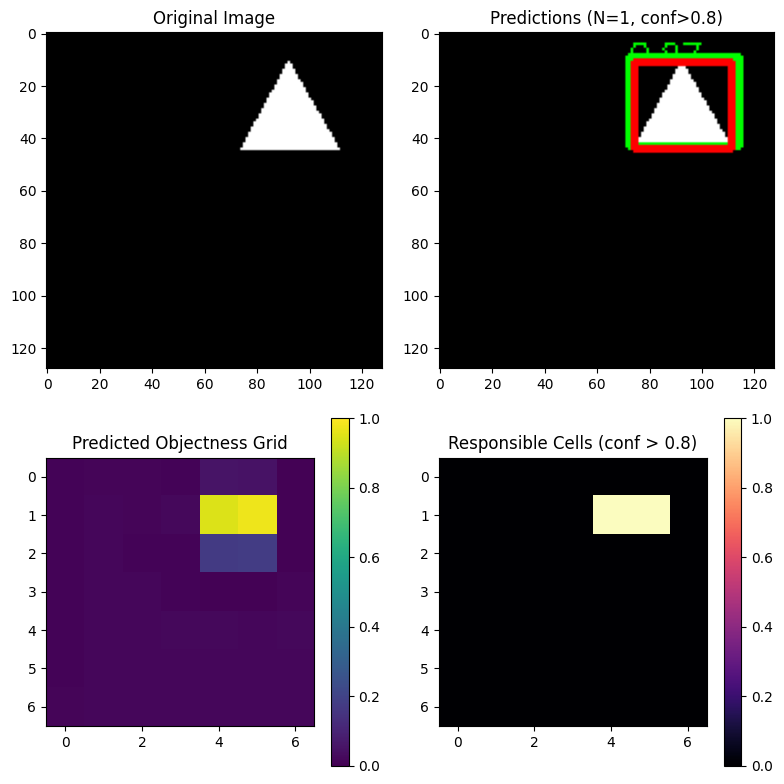

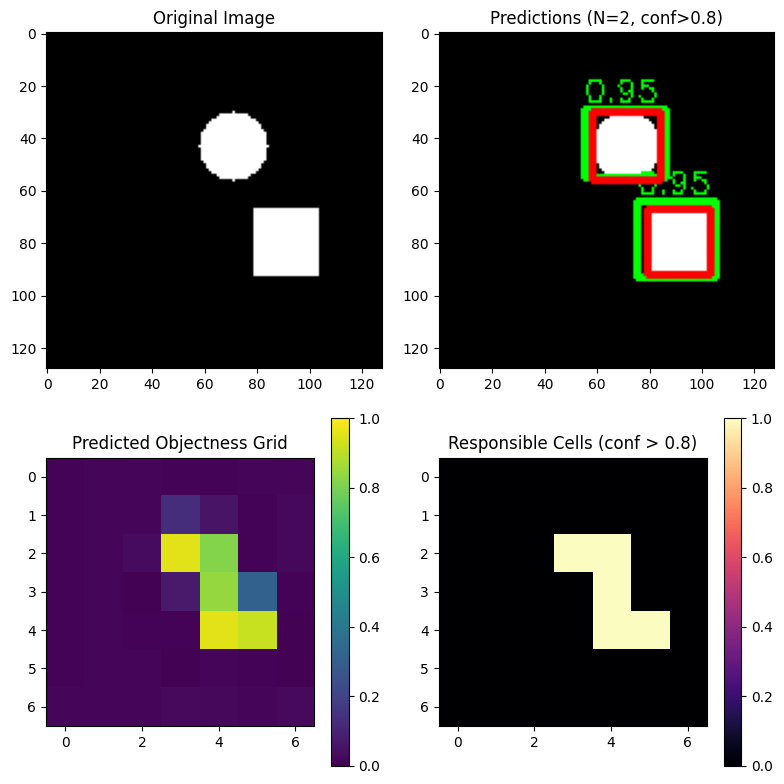

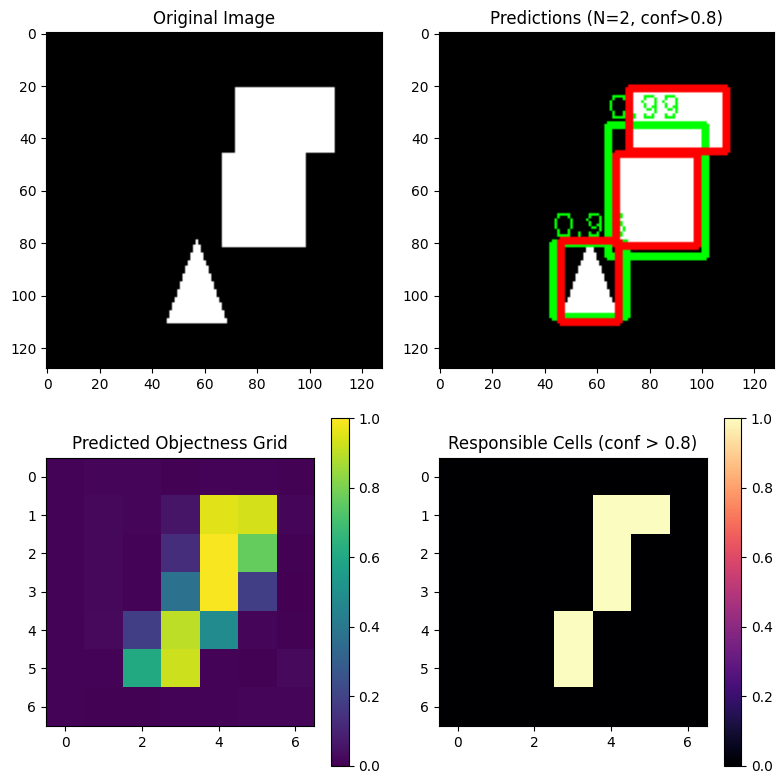

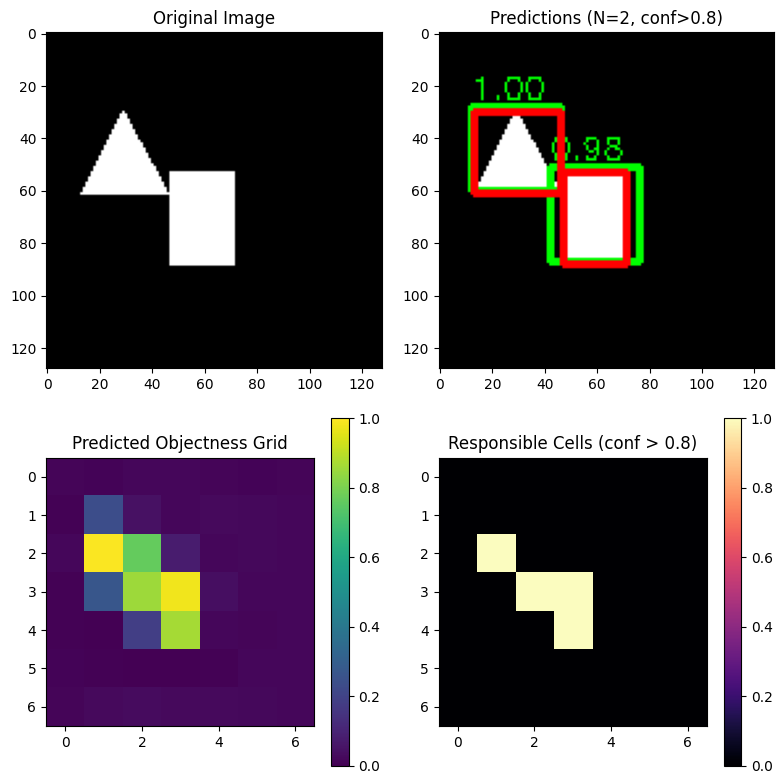

In [10]:
# Postprocess YOLO output with NMS (supports cell-relative coordinates)
def yolo_postprocess(pred, conf_thresh=0.8, iou_thresh=0.1):    
    S = pred.shape[0]
    boxes, scores = [], []

    # Convert cell-relative predictions to global image coordinates
    for cy in range(S):
        for cx in range(S):
            x_rel, y_rel, w, h, conf = pred[cy, cx]
            if conf < conf_thresh:
                continue

            # Convert to global normalized coordinates
            x = (cx + x_rel) / S
            y = (cy + y_rel) / S

            # Convert to absolute pixel coordinates
            x1 = (x - w / 2) * IMG_SIZE
            y1 = (y - h / 2) * IMG_SIZE
            x2 = (x + w / 2) * IMG_SIZE
            y2 = (y + h / 2) * IMG_SIZE

            boxes.append([x1, y1, x2, y2])
            scores.append(conf)

    if len(boxes) == 0:
        return [], []

    boxes = torch.tensor(boxes, dtype=torch.float32)
    scores = torch.tensor(scores, dtype=torch.float32)

    # Apply Non-Maximum Suppression
    keep = ops.nms(boxes, scores, iou_thresh)
    boxes = boxes[keep].numpy()
    scores = scores[keep].numpy()

    return boxes, scores


# Visualize predictions with objectness maps
def visualize_prediction(model, dataset, idx=0,
                         conf_thresh=0.8, iou_thresh=0.1,
                         grid_size=S, img_size=IMG_SIZE):
    model.eval()

    img_t, target = dataset[idx]
    with torch.no_grad():
        pred = model(img_t.unsqueeze(0))[0].cpu().numpy()  # (S, S, 5)

    boxes, scores = yolo_postprocess(pred, conf_thresh, iou_thresh)

    # Convert image for plotting
    img = img_t.permute(1, 2, 0).numpy().astype(np.uint8).copy()
    img_pred = img.copy()

    # Draw predicted boxes (green)
    for (x1, y1, x2, y2), conf in zip(boxes, scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(img_pred, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_pred, f"{conf:.2f}",
                    (x1, max(12, y1 - 3)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    # Draw ground truth (red)
    for (gx1, gy1, gx2, gy2) in target["boxes"].numpy().astype(int):
        cv2.rectangle(img_pred, (gx1, gy1), (gx2, gy2), (255, 0, 0), 2)

    # Build objectness maps
    objectness = pred[..., 4]  # (S, S)
    resp_cells = (objectness > conf_thresh).astype(float)

    # ---- 2×2 Visualization ----
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    # (1) Original image
    axes[0,0].imshow(img)
    axes[0,0].set_title("Original Image")

    # (2) Prediction + GT
    axes[0,1].imshow(img_pred)
    axes[0,1].set_title(f"Predictions (N={len(boxes)}, conf>{conf_thresh})")

    # (3) Objectness grid
    im1 = axes[1,0].imshow(objectness, cmap="viridis", vmin=0, vmax=1)
    axes[1,0].set_title("Predicted Objectness Grid")
    fig.colorbar(im1, ax=axes[1,0])

    # (4) Responsibility map (> conf_thresh)
    im2 = axes[1,1].imshow(resp_cells, cmap="magma", vmin=0, vmax=1)
    axes[1,1].set_title(f"Responsible Cells (conf > {conf_thresh})")
    fig.colorbar(im2, ax=axes[1,1])

    plt.tight_layout()
    plt.show()


# Try a few samples
for i in range(4):
    visualize_prediction(model, val_ds, idx=i)


Finally, we save the trained model weights for later fine-tuning:

In [11]:
# Save trained model weights 
save_path = "mini_yolo_shapes.pth"
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to: {save_path}")

Model weights saved to: mini_yolo_shapes.pth


Great, we have successfully trained a tiny YOLO model for object detection - I hope this demonstration helped you understand one of the most popular detectors to date!